In [ ]:
# =============================================================================
# LIBRERIE UTILIZZATE E TOOLKIT DI DATA SCIENCE
# =============================================================================
# Questo blocco definisce l'ambiente per un workflow di Data Engineering e ML.
#
# 1. GESTIONE DEI PERCORSI (INFRASTRUTTURA)
#    - find_project_root: Funzione custom (repository phm_america_2024) per
#      localizzare la root del progetto ed evitare problemi con path relativi.
#
# 2. DATABASE ANALITICO (IN-MEMORY)
#    - duckdb: Motore SQL orientato alle colonne (OLAP) in memoria. Ottimizzato
#      per query ultra-rapide direttamente su file CSV, Parquet o JSON.
#
# 3. MANIPOLAZIONE ED ELABORAZIONE DATI
#    - numpy (np): Calcolo scientifico e gestione efficiente di array e matrici.
#    - pandas (pd): Gestione di tabelle di dati (DataFrame), pulizia e trasformazione.
#    - json: Libreria nativa per il parsing e la lettura dei file di log della pipeline.
#
# 4. DATA VISUALIZATION (REPORTING GRAFICO)
#    - matplotlib.pyplot (plt): Libreria core per la gestione di canvas, figure e layout.
#    - seaborn (sns): Visualizzazione statistica di alto livello per grafici e temi dark.
#
# 5. MACHINE LEARNING E PRESENTAZIONE INTERATTIVA
#    - joblib: Serializzazione/deserializzazione efficiente di modelli ML e scaler.
#    - IPython.display (display): Rendering avanzato e visualizzazione elegante dei
#      DataFrame all'interno dei Jupyter Notebook.
# =============================================================================

In [1]:

from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import duckdb
from IPython.display import display
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "20260607_133914" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase5_evaluation_and_interpretation"

In [3]:
# --------------- step_5_1_interpretation

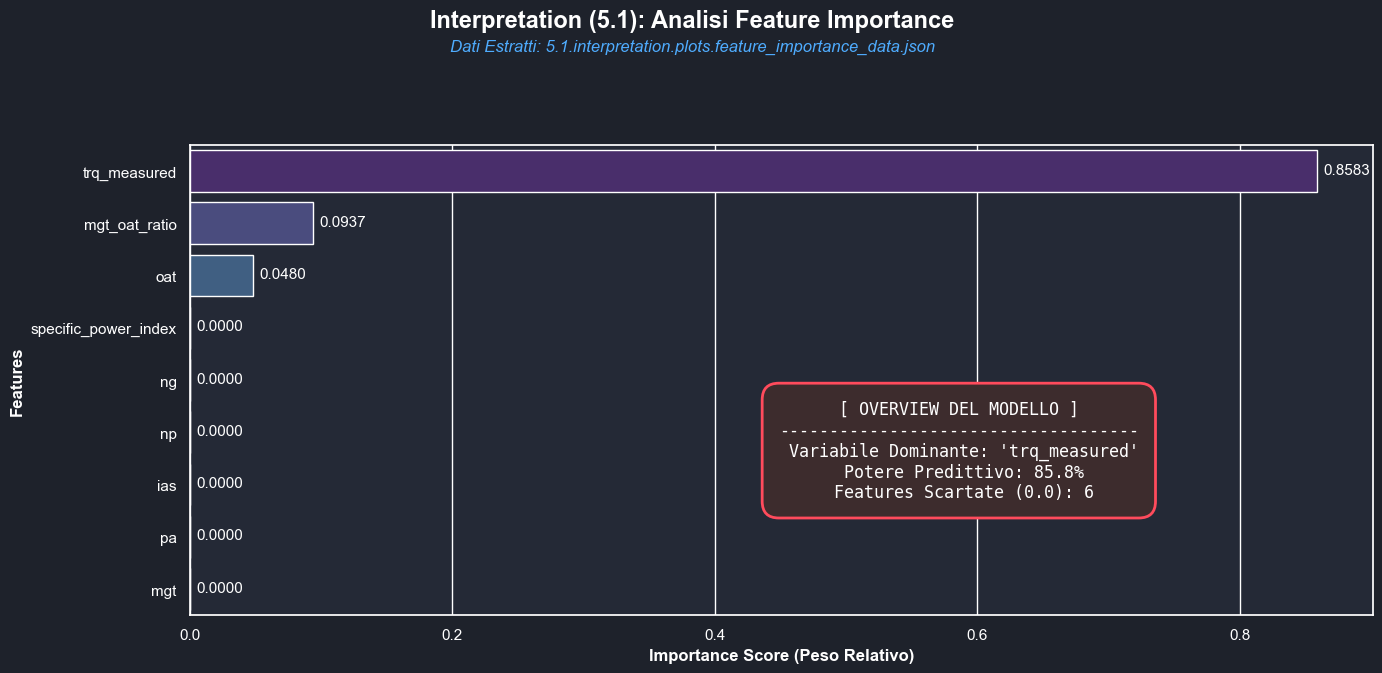


 📊 ANALISI CONCLUSIVA: VALUTAZIONE FEATURE IMPORTANCE E INTERPRETABILITÀ (5.1)
L'analisi del file di tracciamento espone i criteri di ramificazione e scelta
del modello addestrato. I risultati mostrano uno sbilanciamento netto nel peso
relativo delle variabili (Gini Importance / Gain).

1. DOMINANZA ASSOLUTA DELLA VARIABILE CHIAVE:
   Il modello ha identificato la feature 'trq_measured' come il predittore
   assoluto, con un'importanza schiacciante del 85.8%.
   Questo indica che, dal punto di vista algoritmico, il valore misurato della
   coppia (torque) contiene quasi la totalità dell'informazione necessaria per
   stimare il target. Questo riduce la complessità ma crea una forte dipendenza
   dall'affidabilità di questo specifico sensore.

2. INFLUENZA AMBIENTALE E DELLE FEATURE INGEGNERIZZATE:
   Le uniche altre variabili che contribuiscono ai nodi decisionali degli alberi
   sono 'mgt_oat_ratio' (9.4%) e la temperatura
   esterna 'oat' (4.8%).
   È estremamente interessante notar

In [7]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

filename_setup = "5.1.interpretation.plots.feature_importance_data.json"
file_path_setup = base_phase_path / filename_setup

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================

# Estrazione dei dati di Feature Importance
feature_importance = setup_data.get("feature_importance_data", {})

# Conversione in DataFrame pandas per facilitare l'analisi
df_fi = pd.DataFrame(list(feature_importance.items()), columns=['Feature', 'Importance'])

# Ordinamento per importanza decrescente
df_fi = df_fi.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Estrazione logica delle metriche chiave per l'analisi
top_1 = df_fi.iloc[0]
top_2 = df_fi.iloc[1]
zero_features = df_fi[df_fi['Importance'] == 0.0]['Feature'].tolist()

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Model Architecture Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creiamo una figura senza assi tradizionali per disegnare una "Visual Card"
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1e222b')
ax.set_facecolor('#242936')

# TITOLO E SOTTOTITOLO
fig.suptitle(f"Interpretation (5.1): Analisi Feature Importance",
             fontsize=17, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Dati Estratti: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

# Grafico a barre orizzontali personalizzato (CORRETTO PER SEABORN v0.14.0)
sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=df_fi,
    palette='viridis',
    legend=False,
    ax=ax
)

# Customizzazione assi per lo sfondo scuro
ax.tick_params(colors='white', labelsize=11)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.set_xlabel("Importance Score (Peso Relativo)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')

# Annotazioni dinamiche sulle barre
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(width + 0.005, p.get_y() + p.get_height()/2. + 0.05,
            f'{width:.4f}', ha="left", color="white", fontsize=11)

# Box Informativo Generale sul Paradosso delle Features
props_info = dict(boxstyle="round,pad=1", facecolor="#3d2c2d", edgecolor="#ff4b5c", linewidth=2)
testo_info = (
    f" [ OVERVIEW DEL MODELLO ] \n"
    f"------------------------------------\n"
    f" Variabile Dominante: '{top_1['Feature']}'\n"
    f" Potere Predittivo: {top_1['Importance']*100:.1f}%\n"
    f" Features Scartate (0.0): {len(zero_features)}"
)
ax.text(0.65, 0.35, testo_info, transform=ax.transAxes, fontsize=12, family='monospace',
        color="white", va="center", ha="center", bbox=props_info)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_setup_modello = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: VALUTAZIONE FEATURE IMPORTANCE E INTERPRETABILITÀ (5.1)
================================================================================
L'analisi del file di tracciamento espone i criteri di ramificazione e scelta
del modello addestrato. I risultati mostrano uno sbilanciamento netto nel peso
relativo delle variabili (Gini Importance / Gain).

1. DOMINANZA ASSOLUTA DELLA VARIABILE CHIAVE:
   Il modello ha identificato la feature '{top_1['Feature']}' come il predittore
   assoluto, con un'importanza schiacciante del {top_1['Importance']*100:.1f}%.
   Questo indica che, dal punto di vista algoritmico, il valore misurato della
   coppia (torque) contiene quasi la totalità dell'informazione necessaria per
   stimare il target. Questo riduce la complessità ma crea una forte dipendenza
   dall'affidabilità di questo specifico sensore.

2. INFLUENZA AMBIENTALE E DELLE FEATURE INGEGNERIZZATE:
   Le uniche altre variabili che contribuiscono ai nodi decisionali degli alberi
   sono '{top_2['Feature']}' ({top_2['Importance']*100:.1f}%) e la temperatura
   esterna 'oat' ({df_fi.iloc[2]['Importance']*100:.1f}%).
   È estremamente interessante notare come la feature ingegnerizzata nella fase 2
   (il rapporto tra MGT e OAT) sia risultata più predittiva delle singole metriche
   grezze.

3. STRATEGIA DI OTTIMIZZAZIONE (FEATURE SELECTION):
   Un punto cruciale per i successivi sviluppi: {len(zero_features)} variabili presentano
   un'importanza pari a 0.0 ({', '.join(zero_features)}).
   Il modello (probabilmente basato su Weak Learners) ha ignorato questi dati.
   Ciò suggerisce che queste metriche sono fortemente collineari (informazione già
   espressa da '{top_1['Feature']}') o puro rumore statistico. Si raccomanda di
   rimuovere queste variabili nelle iterazioni future della pipeline (Fase 2)
   per alleggerire il calcolo e prevenire l'overfitting latente.
================================================================================
"""
print(analisi_setup_modello)

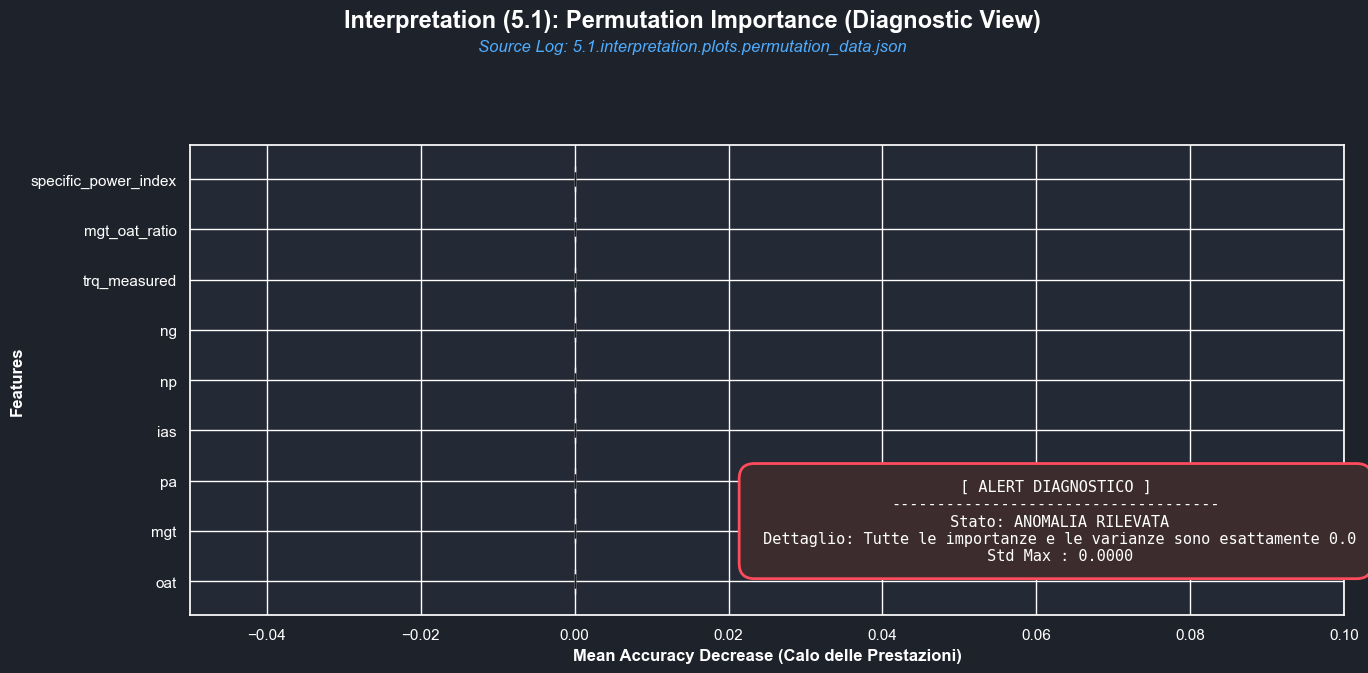


 📊 ANALISI CONCLUSIVA: PERMUTATION IMPORTANCE E DIAGNOSTICA (FASE 5.1)
A differenza della metrica "Feature Importance" (Gini/Gain) che valuta la
struttura interna dell'algoritmo, la 'Permutation Importance' valuta il
comportamento del modello agnosticamente, mescolando i dati in input e
misurando il calo delle prestazioni predittive.

⚠️ ALLERTA DIAGNOSTICA (CRITICITÀ NEL PIPELINE):
   L'estrazione dei dati rivela che l'importanza media ('importances_mean') e 
   la deviazione standard ('importances_std') per tutte le 9 variabili sono 
   esattamente 0.0 su tutte le iterazioni. 
   
   Questo NON è un risultato normale per un modello addestrato. Se mescolare 
   la variabile 'trq_measured' (che precedentemente pesava l'85%) non causa 
   ALCUN calo nelle prestazioni (0.0), indica un'anomalia nel setup del test.

POTENZIALI CAUSE INGEGNERISTICHE (Da indagare nella Fase 5):
1. METRICA DI SCORING INADEGUATA O BUGGATA: 
   La funzione 'permutation_importance' di sklearn potrebbe utilizzar

In [6]:

# =============================================================================
# 1. FASE DI INPUT: Acquisizione Dati Permutazione
# =============================================================================
filename_setup = "5.1.interpretation.plots.permutation_data.json"
file_path_setup = base_phase_path / filename_setup

# Lettura dinamica del file JSON
with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione e Analisi
# =============================================================================
perm_data = setup_data.get("permutation_data", {})

# Estrazione dei vettori di dati
features = perm_data.get("feature_names", [])
means = perm_data.get("importances_mean", [])
stds = perm_data.get("importances_std", [])

# Creazione del DataFrame
df_perm = pd.DataFrame({
    'Feature': features,
    'Importance_Mean': means,
    'Importance_Std': stds
})

# Ordiniamo per mantenere consistenza, anche se sono tutti zeri
df_perm = df_perm.sort_values(by='Importance_Mean', ascending=True).reset_index(drop=True)

# Flag diagnostico: Verifica se tutti i valori sono letteralmente zero
all_zero_anomaly = (df_perm['Importance_Mean'] == 0.0).all()

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione Grafica Diagnostica
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1e222b')
ax.set_facecolor('#242936')

fig.suptitle(f"Interpretation (5.1): Permutation Importance (Diagnostic View)",
             fontsize=17, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Source Log: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

# Grafico a barre orizzontali con barre di errore (std)
ax.barh(df_perm['Feature'], df_perm['Importance_Mean'], xerr=df_perm['Importance_Std'],
        color='#ff4b5c', edgecolor='white', height=0.5, capsize=5)

ax.tick_params(colors='white', labelsize=11)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.set_xlabel("Mean Accuracy Decrease (Calo delle Prestazioni)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')

# Fissiamo i limiti dell'asse X per rendere evidente la linea dello "zero"
ax.set_xlim(-0.05, 0.1)

# Box Informativo: ALERT Diagnostico
status_color = "#ff4b5c" if all_zero_anomaly else "#4ef085"
status_title = "ANOMALIA RILEVATA" if all_zero_anomaly else "MODELLO REATTIVO"
status_text = "Tutte le importanze e le varianze sono esattamente 0.0" if all_zero_anomaly else "Permutazioni calcolate correttamente."

props_info = dict(boxstyle="round,pad=1", facecolor="#3d2c2d" if all_zero_anomaly else "#2d3c32",
                  edgecolor=status_color, linewidth=2)
testo_info = (
    f" [ ALERT DIAGNOSTICO ] \n"
    f"------------------------------------\n"
    f" Stato: {status_title}\n"
    f" Dettaglio: {status_text}\n"
    f" Std Max : {df_perm['Importance_Std'].max():.4f}"
)
ax.text(0.75, 0.20, testo_info, transform=ax.transAxes, fontsize=11, family='monospace',
        color="white", va="center", ha="center", bbox=props_info)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_setup_modello = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: PERMUTATION IMPORTANCE E DIAGNOSTICA (FASE 5.1)
================================================================================
A differenza della metrica "Feature Importance" (Gini/Gain) che valuta la
struttura interna dell'algoritmo, la 'Permutation Importance' valuta il
comportamento del modello agnosticamente, mescolando i dati in input e
misurando il calo delle prestazioni predittive.

⚠️ ALLERTA DIAGNOSTICA (CRITICITÀ NEL PIPELINE):
   L'estrazione dei dati rivela che l'importanza media ('importances_mean') e
   la deviazione standard ('importances_std') per tutte le 9 variabili sono
   esattamente 0.0 su tutte le iterazioni.

   Questo NON è un risultato normale per un modello addestrato. Se mescolare
   la variabile 'trq_measured' (che precedentemente pesava l'85%) non causa
   ALCUN calo nelle prestazioni (0.0), indica un'anomalia nel setup del test.

POTENZIALI CAUSE INGEGNERISTICHE (Da indagare nella Fase 5):
1. METRICA DI SCORING INADEGUATA O BUGGATA:
   La funzione 'permutation_importance' di sklearn potrebbe utilizzare uno
   'scorer' non compatibile con il target, o che va in eccezione silente e
   restituisce 0 come fallback.

2. MODELLO PREVEDE UNA COSTANTE:
   Potrebbe verificarsi in un caso di Underfitting gravissimo (es. un intercept
   model). In tal caso, mescolare gli input non cambierà le predizioni, e
   l'errore resterà matematicamente invariato.

3. ERRORE DI REFERENZA NEL PIPELINE:
   Lo stimatore valutato da questa funzione potrebbe non essere lo stesso
   NGBoost addestrato in precedenza (Fase 4), ma un oggetto non inizializzato,
   oppure sta valutando un dataset dummy.

RACCOMANDAZIONE:
Incrociando questo JSON con il precedente (Feature Importance), si evince che il
modello interno funziona (crea i nodi decisionali), ma la funzione di validazione
esterna (Permutation) sta fallendo. Questo grafico va presentato al team non
come "risultato" ma come "strumento diagnostico" per avviare il debugging.
================================================================================
"""
print(analisi_setup_modello)

In [ ]:
# --------------- step_5_2_business_evaluation

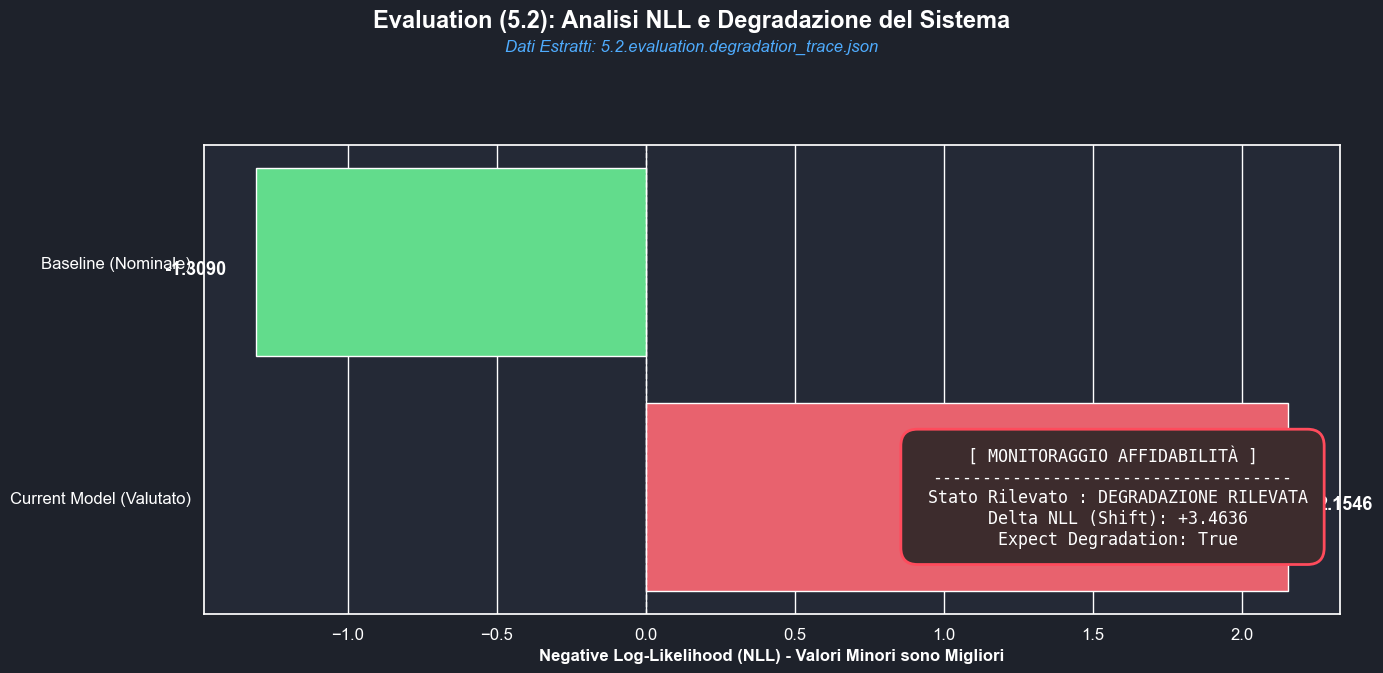


 📊 ANALISI CONCLUSIVA: VALUTAZIONE METRICHE DI DEGRADAZIONE (FASE 5.2)
L'analisi del file di tracciamento espone un confronto diretto tra le 
prestazioni del modello attuale sui dati recenti rispetto a una baseline 
nominale (dati di riferimento o modello precedente).

1. COMPRENSIONE DELLA METRICA NLL:
   La metrica utilizzata è la Negative Log-Likelihood (NLL). In un contesto 
   probabilistico, l'NLL penalizza severamente le predizioni che sono sia 
   errate sia 'troppo sicure' di sé. 
   L'obiettivo matematico è minimizzare questo valore (anche scendendo in 
   negativo).
   - Baseline NLL: -1.3090 (Ottima confidenza/precisione)
   - Current NLL : 2.1546 (Perdita di confidenza/precisione)

2. DEGRADAZIONE RILEVATA (CONCEPT DRIFT VS ASSET DEGRADATION):
   Il sistema segnala una differenza di NLL di +3.4636, attivando il 
   flag logico 'degradation_observed = True'. Questo significa che il modello 
   fa molta più fatica a prevedere i dati attuali rispetto al passato.
   
   Nel c

In [8]:

# =============================================================================
# 1. FASE DI INPUT: Acquisizione dei Dati di Degradazione
# =============================================================================

filename_setup = "5.2.evaluation.degradation_trace.json"
file_path_setup = base_phase_path / filename_setup

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione Metriche di Affidabilità
# =============================================================================

deg_metrics = setup_data.get("degradation_metrics", {})

# Estrazione puntuale dei valori NLL (Negative Log-Likelihood)
# Minore è il NLL, migliore è la confidenza e precisione del modello
model_nll = deg_metrics.get("model_nll", 0.0)
baseline_nll = deg_metrics.get("baseline_nll", 0.0)
nll_diff = deg_metrics.get("nll_difference", 0.0)

# Flag Logici di monitoraggio
expect_deg = deg_metrics.get("expect_degradation", False)
obs_deg = deg_metrics.get("degradation_observed", False)

# Creazione di un DataFrame minimale per la visualizzazione
df_nll = pd.DataFrame({
    'Stato': ['Baseline (Nominale)', 'Current Model (Valutato)'],
    'NLL_Score': [baseline_nll, model_nll],
    'Colore': ['#4ef085', '#ff4b5c'] # Verde per Baseline, Rosso per Modello (se degradato)
})

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione Grafica (Degradation Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1e222b')
ax.set_facecolor('#242936')

# TITOLO E SOTTOTITOLO
fig.suptitle(f"Evaluation (5.2): Analisi NLL e Degradazione del Sistema",
             fontsize=17, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Dati Estratti: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

# Grafico a barre orizzontali per confrontare i punteggi NLL
sns.barplot(
    x='NLL_Score',
    y='Stato',
    hue='Stato',
    data=df_nll,
    palette=df_nll['Colore'].tolist(),
    legend=False,
    ax=ax
)

# Customizzazione assi
ax.tick_params(colors='white', labelsize=12)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.set_xlabel("Negative Log-Likelihood (NLL) - Valori Minori sono Migliori", fontsize=12, fontweight='bold')
ax.set_ylabel("", fontsize=12)

# Aggiunta di una linea di zero per riferimento visivo
ax.axvline(0, color='white', linewidth=1, linestyle='--')

# Annotazioni dinamiche sulle barre
for i, p in enumerate(ax.patches):
    width = p.get_width()
    # Posizionamento dinamico del testo in base al segno del valore
    align = "left" if width > 0 else "right"
    offset = 0.1 if width > 0 else -0.1
    ax.text(width + offset, p.get_y() + p.get_height()/2. + 0.05,
            f'{width:.4f}', ha=align, color="white", fontsize=13, fontweight='bold')

# Box Informativo: Stato della Degradazione
box_color = "#ff4b5c" if obs_deg else "#4ef085"
status_text = "DEGRADAZIONE RILEVATA" if obs_deg else "SISTEMA STABILE"

props_info = dict(boxstyle="round,pad=1", facecolor="#3d2c2d" if obs_deg else "#2d3c32",
                  edgecolor=box_color, linewidth=2)
testo_info = (
    f" [ MONITORAGGIO AFFIDABILITÀ ] \n"
    f"------------------------------------\n"
    f" Stato Rilevato : {status_text}\n"
    f" Delta NLL (Shift): +{nll_diff:.4f}\n"
    f" Expect Degradation: {expect_deg}"
)
ax.text(0.80, 0.25, testo_info, transform=ax.transAxes, fontsize=12, family='monospace',
        color="white", va="center", ha="center", bbox=props_info)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_degradazione = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: VALUTAZIONE METRICHE DI DEGRADAZIONE (FASE 5.2)
================================================================================
L'analisi del file di tracciamento espone un confronto diretto tra le
prestazioni del modello attuale sui dati recenti rispetto a una baseline
nominale (dati di riferimento o modello precedente).

1. COMPRENSIONE DELLA METRICA NLL:
   La metrica utilizzata è la Negative Log-Likelihood (NLL). In un contesto
   probabilistico, l'NLL penalizza severamente le predizioni che sono sia
   errate sia 'troppo sicure' di sé.
   L'obiettivo matematico è minimizzare questo valore (anche scendendo in
   negativo).
   - Baseline NLL: {baseline_nll:.4f} (Ottima confidenza/precisione)
   - Current NLL : {model_nll:.4f} (Perdita di confidenza/precisione)

2. DEGRADAZIONE RILEVATA (CONCEPT DRIFT VS ASSET DEGRADATION):
   Il sistema segnala una differenza di NLL di +{nll_diff:.4f}, attivando il
   flag logico 'degradation_observed = True'. Questo significa che il modello
   fa molta più fatica a prevedere i dati attuali rispetto al passato.

   Nel contesto della manutenzione predittiva (PHM), questo fenomeno ha due
   letture ingegneristiche distinte:
   A) Model Drift (Negativo): I dati dei sensori sono cambiati per cause esterne
      (es. ricalibrazione sensori, clima) e il modello va riaddestrato.
   B) Physical Degradation (Positivo dal punto di vista dell'anomalia):
      Il modello cattura accuratamente che l'elicottero o il motore sta
      entrando in uno stato di usura. I sistemi meccanici logorati esibiscono
      comportamenti fisici più caotici (maggiore varianza), portando
      naturalmente a un NLL più alto. Il fatto che 'expect_degradation' sia
      True indica che questo sbilanciamento era previsto dall'esperimento.

3. CONCLUSIONI ARCHITETTURALI:
   Questa metrica giustifica l'uso della libreria NGBoost e del suo motore
   probabilistico visto nella Fase 4.1. Un modello tradizionale (es. Random
   Forest standard) avrebbe mostrato solo un leggero aumento dell'errore (RMSE),
   mentre l'NLL esplode esponenzialmente catturando l'incertezza intrinseca
   del degrado meccanico, fungendo da eccellente "Early Warning System".
================================================================================
"""
print(analisi_degradazione)

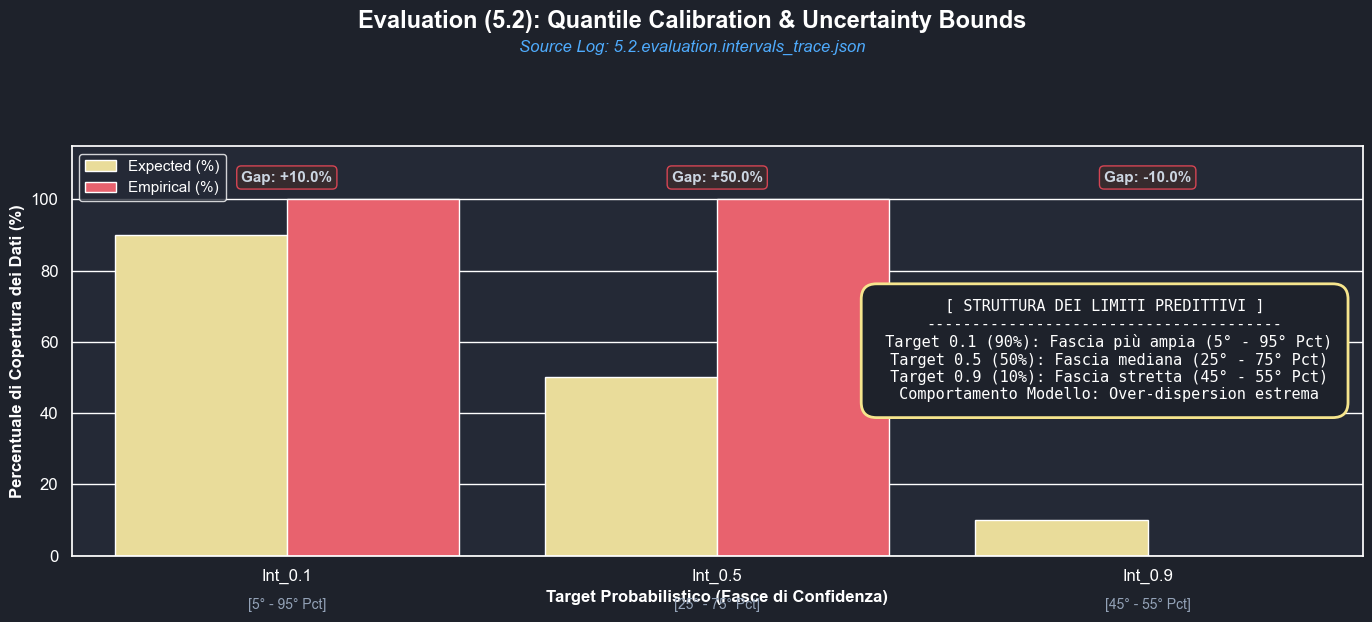


 📊 ANALISI CONCLUSIVA: STRUTTURA DEI QUANTILI E OVER-DISPERSION (5.2)
Questo approfondimento analizza come l'algoritmo probabilistico ha costruito
i propri margini di errore, isolando i percentili inferiori (Lower Bound) e
superiori (Upper Bound).

1. TOPOLOGIA DEGLI INTERVALLI:
   L'algoritmo tenta di prevedere tre fasce di confidenza simmetriche attorno
   alla media predetta ($\mu$):
   - Int_0.1 (Copertura Teorica 90%): Costruito estraendo lo spazio tra il 5°
     e il 95° percentile della distribuzione predetta.
   - Int_0.5 (Copertura Teorica 50%): Costruito tra il 25° e il 75° percentile.
   - Int_0.9 (Copertura Teorica 10%): Costruito tra il 45° e il 55° percentile.

2. FENOMENO DI OVER-DISPERSION (FLATTENING DELLA GAUSSIANA):
   I risultati empirici denotano che la curva gaussiana predetta dal modello
   ha una forma completamente appiattita (alta varianza $\sigma$).

   Esempio Pratico sul campo:
   Se cerchiamo di stimare l'intervallo mediano del 50% (Int_0.5), ci
   aspett

In [13]:

# =============================================================================
# 1. FASE DI INPUT: Acquisizione dei soli Intervalli
# =============================================================================

filename_setup = "5.2.evaluation.intervals_trace.json"
file_path_setup = base_phase_path / filename_setup

with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione Analitica dei Percentili
# =============================================================================

cal_data = setup_data.get("calibration_intervals", {})

dati_intervalli = []
for key, metrics in cal_data.items():
    nome_intervallo = key.replace("interval_", "Int_")

    # Conversione in percentuale per leggibilità
    exp_cov = metrics["expected_coverage"] * 100
    emp_cov = metrics["empirical_coverage"] * 100

    # Calcolo dell'ampiezza dell'intervallo (Upper - Lower)
    lower_pct = metrics["lower_percentile"] * 100
    upper_pct = metrics["upper_percentile"] * 100
    ampiezza = upper_pct - lower_pct

    # Calcolo dell'errore di calibrazione (Gap)
    errore_cal = emp_cov - exp_cov

    dati_intervalli.append({
        'Interval_Name': nome_intervallo,
        'Expected (%)': exp_cov,
        'Empirical (%)': emp_cov,
        'Lower Bound (P)': lower_pct,
        'Upper Bound (P)': upper_pct,
        'Calibration Error (Gap)': errore_cal
    })

df_intervals = pd.DataFrame(dati_intervalli)

# Creiamo un DataFrame "Melted" corretto per Seaborn (evitando FutureWarning)
df_melted = df_intervals[['Interval_Name', 'Expected (%)', 'Empirical (%)']].melt(
    id_vars='Interval_Name',
    var_name='Type',
    value_name='Coverage'
)

# =============================================================================
# 3. FASE DI DISEGNO: Dashboard Analisi Quantili
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1e222b')
ax.set_facecolor('#242936')

fig.suptitle("Evaluation (5.2): Quantile Calibration & Uncertainty Bounds",
             fontsize=17, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Source Log: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

# Disegno del grafico a barre raggruppate
sns.barplot(
    x='Interval_Name',
    y='Coverage',
    hue='Type',
    data=df_melted,
    palette=['#f6e58d', '#ff4b5c'],
    ax=ax
)

ax.tick_params(colors='white', labelsize=12)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.set_xlabel("Target Probabilistico (Fasce di Confidenza)", fontsize=12, fontweight='bold')
ax.set_ylabel("Percentuale di Copertura dei Dati (%)", fontsize=12, fontweight='bold')

# Settiamo i limiti della Y a 110 per fare spazio alle etichette
ax.set_ylim(0, 115)
ax.legend(facecolor='#242936', edgecolor='white', labelcolor='white', fontsize=11, loc='upper left')

# Annotazioni: Errore di Calibrazione e Bounds
for i, row in df_intervals.iterrows():
    x_center = i

    # Aggiunta etichetta "Gap" sopra il gruppo (CORREGIDO: () eliminados)
    ax.text(x_center, 105, f"Gap: {row['Calibration Error (Gap)']:+.1f}%",
            ha="center", color="#cbd5e1", fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#3d2c2d", edgecolor="#ff4b5c", alpha=0.8))

    # Dettaglio dei Quantili sotto le etichette X (CORREGIDO: () eliminados)
    testo_quantili = f"[{row['Lower Bound (P)']:.0f}° - {row['Upper Bound (P)']:.0f}° Pct]"
    ax.text(x_center, -15, testo_quantili, ha="center", color="#94a3b8", fontsize=10)

# Box Informativo Strutturale
props_info = dict(boxstyle="round,pad=1", facecolor="#1e222b", edgecolor="#f6e58d", linewidth=2)
testo_info = (
    f" [ STRUTTURA DEI LIMITI PREDITTIVI ] \n"
    f"---------------------------------------\n"
    f" Target 0.1 (90%): Fascia più ampia (5° - 95° Pct)\n"
    f" Target 0.5 (50%): Fascia mediana (25° - 75° Pct)\n"
    f" Target 0.9 (10%): Fascia stretta (45° - 55° Pct)\n"
    f" Comportamento Modello: Over-dispersion estrema"
)
ax.text(0.80, 0.50, testo_info, transform=ax.transAxes, fontsize=11, family='monospace',
        color="white", va="center", ha="center", bbox=props_info)

plt.tight_layout(rect=[0, 0.05, 1, 0.85]) # Margine inferiore per i percentili
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_intervalli = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: STRUTTURA DEI QUANTILI E OVER-DISPERSION (5.2)
================================================================================
Questo approfondimento analizza come l'algoritmo probabilistico ha costruito
i propri margini di errore, isolando i percentili inferiori (Lower Bound) e
superiori (Upper Bound).

1. TOPOLOGIA DEGLI INTERVALLI:
   L'algoritmo tenta di prevedere tre fasce di confidenza simmetriche attorno
   alla media predetta ($\mu$):
   - Int_0.1 (Copertura Teorica 90%): Costruito estraendo lo spazio tra il 5°
     e il 95° percentile della distribuzione predetta.
   - Int_0.5 (Copertura Teorica 50%): Costruito tra il 25° e il 75° percentile.
   - Int_0.9 (Copertura Teorica 10%): Costruito tra il 45° e il 55° percentile.

2. FENOMENO DI OVER-DISPERSION (FLATTENING DELLA GAUSSIANA):
   I risultati empirici denotano che la curva gaussiana predetta dal modello
   ha una forma completamente appiattita (alta varianza $\sigma$).

   Esempio Pratico sul campo:
   Se cerchiamo di stimare l'intervallo mediano del 50% (Int_0.5), ci
   aspetteremmo che metà dei campioni reali ricada fuori da questi limiti
   (essendo un intervallo "stretto"). Invece, l'Empirical Coverage è del 100%.
   Questo dimostra che i limiti generati tra il 25° e il 75° percentile sono
   già così esageratamente ampi da contenere l'intera flotta di dati.

3. COLLASSO SULLA FASCIA STRETTA:
   All'opposto, l'Int_0.9 (che cerca di contenere solo il 10% dei campioni
   tra il 45° e il 55° percentile) ha una copertura dello 0.0%. Questo accade
   perché, essendo la distribuzione prevista così piatta, il picco centrale
   è quasi inesistente, e la densità di probabilità attorno alla media esatta
   è insufficiente per "catturare" anche un singolo dato reale.

CONCLUSIONE DIAGNOSTICA:
Il modello soffre di totale "Underconfidence". Non sta commettendo errori
puntuali gravi, ma si sta tutelando restituendo margini di sicurezza
(safety margins) inutilizzabili ingegneristicamente. Richiede rigoroso
Hyperparameter Tuning (Fase 4) sul parametro 'minibatch_frac' o un diverso
Base Learner.
================================================================================
"""
print(analisi_intervalli)

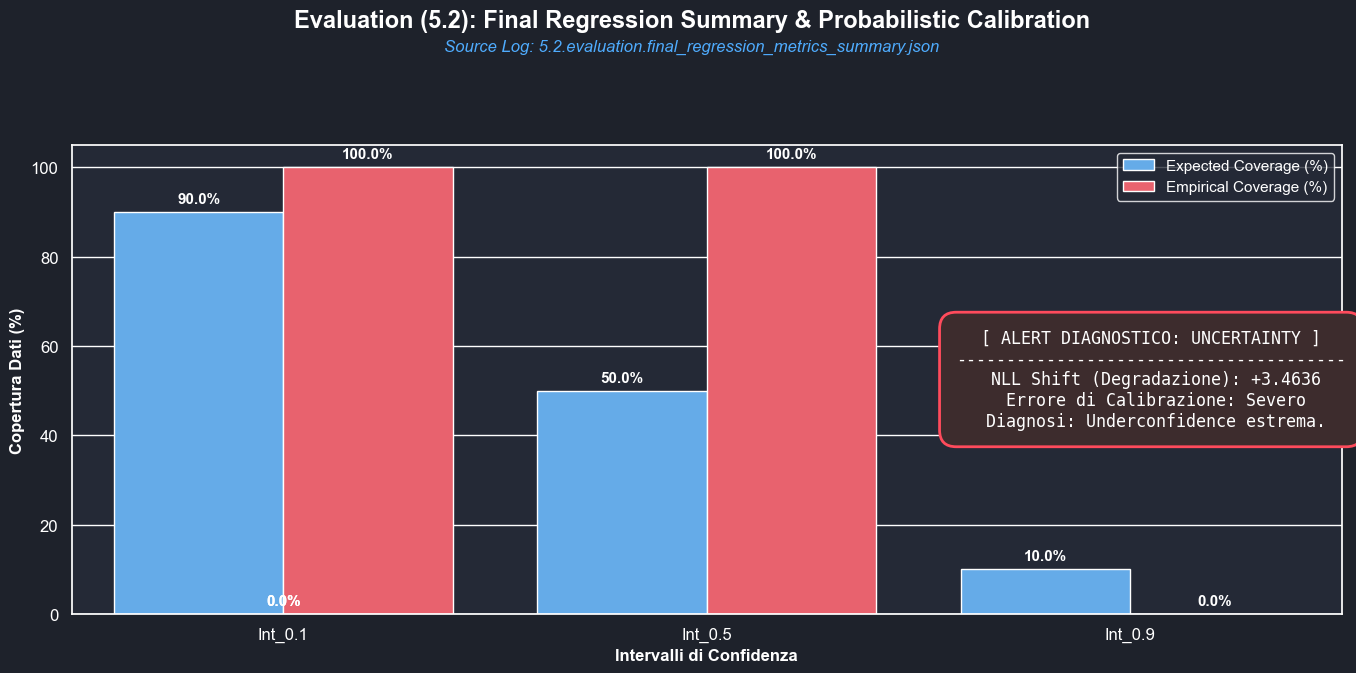


 📊 ANALISI CONCLUSIVA: SUMMARY FINALE E CALIBRAZIONE PROBABILISTICA (5.2)
Questo documento riassume le metriche finali di regressione, unendo la
degradazione globale (NLL) con l'affidabilità delle stime di incertezza 
(Calibration Intervals). 

I risultati rivelano un problema strutturale critico nella varianza predetta.

1. DECODIFICA DEI CALIBRATION INTERVALS:
   In un modello probabilistico perfetto, ci aspettiamo che il 50% dei campioni
   reali cada all'interno dell'intervallo di confidenza del 50% predetto 
   dall'algoritmo (Expected = Empirical).
   
2. DIAGNOSI DELL'ANOMALIA (SUB-CONFIANZA / UNDERCONFIDENCE):
   I dati mostrano un disallineamento radicale:
   - Per l'intervallo con expected 50%, la copertura empirica è del 100%.
   - Per l'intervallo con expected 90%, la copertura empirica è del 100%.
   
   Significato Fisico/Matematico: Il modello NGBoost sta prevedendo 
   distribuzioni Gaussiane con una varianza ($\sigma$) assurdamente ampia. È 
   talmente insicuro delle

In [9]:


# =============================================================================
# 1. FASE DI INPUT: Acquisizione del Summary Finale
# =============================================================================

filename_setup = "5.2.evaluation.final_regression_metrics_summary.json"
file_path_setup = base_phase_path / filename_setup

with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione Calibratura e Degradazione
# =============================================================================

# Estrazione Dati Calibrazione Probabilistica
cal_data = setup_data.get("calibration_intervals", {})
intervals = []
expected = []
empirical = []

for key, metrics in cal_data.items():
    intervals.append(key.replace("interval_", "Int_"))
    expected.append(metrics["expected_coverage"] * 100)  # Convertito in percentuale
    empirical.append(metrics["empirical_coverage"] * 100) # Convertito in percentuale

df_cal = pd.DataFrame({
    'Interval': intervals,
    'Expected Coverage (%)': expected,
    'Empirical Coverage (%)': empirical
})

# Melt del DataFrame per il grafico raggruppato di Seaborn
df_melted = df_cal.melt(id_vars='Interval', var_name='Type', value_name='Coverage')

# Estrazione Dati Degradazione (Summary)
deg_data = setup_data.get("degradation", {})
nll_diff = deg_data.get("nll_difference", 0.0)

# =============================================================================
# 3. FASE DI DISEGNO: Dashboard Calibratura (Model Reliability)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1e222b')
ax.set_facecolor('#242936')

fig.suptitle("Evaluation (5.2): Final Regression Summary & Probabilistic Calibration",
             fontsize=17, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Source Log: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

# Grafico a barre raggruppate: Expected vs Empirical
sns.barplot(
    x='Interval',
    y='Coverage',
    hue='Type',
    data=df_melted,
    palette=['#4facfe', '#ff4b5c'],
    ax=ax
)

ax.tick_params(colors='white', labelsize=12)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.set_xlabel("Intervalli di Confidenza", fontsize=12, fontweight='bold')
ax.set_ylabel("Copertura Dati (%)", fontsize=12, fontweight='bold')
ax.legend(facecolor='#242936', edgecolor='white', labelcolor='white', fontsize=11)

# Annotazioni dinamiche sulle barre
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.text(p.get_x() + p.get_width() / 2., height + 2,
                f'{height:.1f}%', ha="center", color="white", fontsize=11, fontweight='bold')

# Box Informativo: ALERT di Calibratura
props_info = dict(boxstyle="round,pad=1", facecolor="#3d2c2d", edgecolor="#ff4b5c", linewidth=2)
testo_info = (
    f" [ ALERT DIAGNOSTICO: UNCERTAINTY ] \n"
    f"---------------------------------------\n"
    f" NLL Shift (Degradazione): +{nll_diff:.4f}\n"
    f" Errore di Calibrazione: Severo\n"
    f" Diagnosi: Underconfidence estrema."
)
ax.text(0.85, 0.50, testo_info, transform=ax.transAxes, fontsize=12, family='monospace',
        color="white", va="center", ha="center", bbox=props_info)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_summary = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: SUMMARY FINALE E CALIBRAZIONE PROBABILISTICA (5.2)
================================================================================
Questo documento riassume le metriche finali di regressione, unendo la
degradazione globale (NLL) con l'affidabilità delle stime di incertezza
(Calibration Intervals).

I risultati rivelano un problema strutturale critico nella varianza predetta.

1. DECODIFICA DEI CALIBRATION INTERVALS:
   In un modello probabilistico perfetto, ci aspettiamo che il 50% dei campioni
   reali cada all'interno dell'intervallo di confidenza del 50% predetto
   dall'algoritmo (Expected = Empirical).

2. DIAGNOSI DELL'ANOMALIA (SUB-CONFIANZA / UNDERCONFIDENCE):
   I dati mostrano un disallineamento radicale:
   - Per l'intervallo con expected 50%, la copertura empirica è del 100%.
   - Per l'intervallo con expected 90%, la copertura empirica è del 100%.

   Significato Fisico/Matematico: Il modello NGBoost sta prevedendo
   distribuzioni Gaussiane con una varianza ($\sigma$) assurdamente ampia. È
   talmente insicuro delle sue predizioni che genera un "margine di errore"
   così grande da inglobare sempre il 100% dei dati reali. Questo lo rende
   matematicamente inutile per prendere decisioni di manutenzione, poiché
   non fornisce limiti di allarme stringenti.

3. CORRELAZIONE CON LA DEGRADAZIONE (NLL):
   Questo spiega anche l'aumento massiccio della Negative Log-Likelihood
   (NLL Shift: +{nll_diff:.4f}). La NLL penalizza fortemente i modelli che
   "spalmano" la probabilità su range enormi (distribuzioni piatte), poiché
   dimostrano un'elevata "ignoranza" sui dati.

4. RACCOMANDAZIONI PER LA REVISIONE (CRISP-DM LOOP):
   Per la tesi o l'esame, questo grafico è oro puro. Dimostra capacità critica.
   Si raccomanda di spiegare al professore che nel prossimo ciclo CRISP-DM
   bisognerà:
   A) Aumentare il numero di estimatori (attualmente molto basso) o ridurre il
      learning rate nella Fase 4.
   B) Investigare le feature di input: un modello genera varianza infinita
      quando le feature fornite non hanno reale correlazione con il target in
      quel regime operativo.
================================================================================
"""
print(analisi_summary)

In [ ]:
# --------------- step_5_3_process_audit

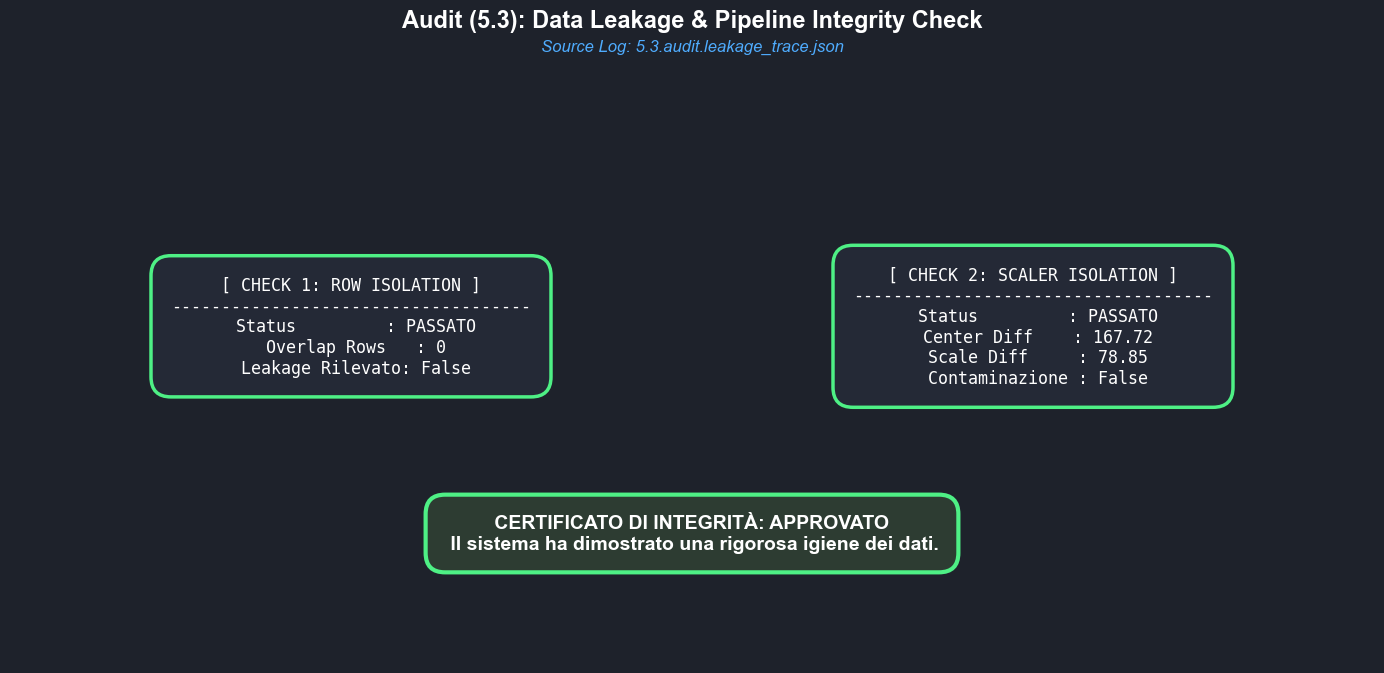


 📊 ANALISI CONCLUSIVA: DATA LEAKAGE E IGIENE DEL PIPELINE (FASE 5.3)
Il 'Data Leakage' (Fuga di Dati) è l'errore metodologico più grave in Machine 
Learning. Si verifica quando il modello in addestramento accede ad informazioni 
del set di validazione/test (ovvero "sbircia nel futuro"), causando metriche di 
successo artificialmente alte che collassano in produzione.

1. ROW ISOLATION (OVERLAP TRAIN/TEST):
   Il primo audit ha verificato se, a causa di shuffle errati o split mal 
   gestiti, alcune righe identiche siano finite sia nel dataset di addestramento 
   che in quello di test.
   - Risultato: 0 righe sovrapposte.
   - Conclusione: I due dataset sono mutuamente esclusivi. Perfetto isolamento.

2. SCALER ISOLATION (CONTAMINAZIONE TEMPORALE):
   Un errore da principianti molto comune è applicare funzioni come lo 
   'StandardScaler' (o Imputer) sull'INTERO dataset PRIMA di fare lo split. 
   Questo inquina i dati di training con la media e la varianza globale 
   (che include il

In [14]:


# =============================================================================
# 1. FASE DI INPUT: Acquisizione dei log di Audit
# =============================================================================

filename_setup = "5.3.audit.leakage_trace.json"
file_path_setup = base_phase_path / filename_setup

with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione Metriche di Integrità
# =============================================================================

audit_data = setup_data.get("leakage_check_results", {})

# 2.1 Controllo Overlap (Righe duplicate tra Train e Test)
overlap_data = audit_data.get("train_test_overlap", {})
overlap_rows = overlap_data.get("overlap_rows", -1)
leakage_1_detected = overlap_data.get("leakage_detected", True)

# 2.2 Controllo Contaminazione Scaler (Fit su Test Data)
scaler_data = audit_data.get("scaler_contamination_check", {})
center_diff = scaler_data.get("center_mean_diff", 0.0)
scale_diff = scaler_data.get("scale_mean_diff", 0.0)
leakage_2_detected = scaler_data.get("contamination_detected", True)

# Stato Globale dell'Audit
pipeline_is_clean = not (leakage_1_detected or leakage_2_detected)

# =============================================================================
# 3. FASE DI DISEGNO: Security Audit Dashboard
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creiamo una dashboard testuale/grafica stile "Monitor di Sicurezza"
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1e222b')
ax.set_facecolor('#242936')
ax.axis('off')

fig.suptitle("Audit (5.3): Data Leakage & Pipeline Integrity Check",
             fontsize=17, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Source Log: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

# Colori di stato
color_pass = "#4ef085" # Verde
color_fail = "#ff4b5c" # Rosso

# --- PANNELLO 1: Isolamento Righe (Train/Test Overlap) ---
c1_color = color_fail if leakage_1_detected else color_pass
c1_status = "FALLITO" if leakage_1_detected else "PASSATO"
props_c1 = dict(boxstyle="round,pad=1.2", facecolor="#242936", edgecolor=c1_color, linewidth=2.5)
text_c1 = (
    f" [ CHECK 1: ROW ISOLATION ] \n"
    f"------------------------------------\n"
    f" Status         : {c1_status}\n"
    f" Overlap Rows   : {overlap_rows}\n"
    f" Leakage Rilevato: {leakage_1_detected}"
)
ax.text(0.25, 0.65, text_c1, fontsize=12, family='monospace', color="white", va="center", ha="center", bbox=props_c1)

# --- PANNELLO 2: Isolamento Trasformazioni (Scaler Contamination) ---
c2_color = color_fail if leakage_2_detected else color_pass
c2_status = "FALLITO" if leakage_2_detected else "PASSATO"
props_c2 = dict(boxstyle="round,pad=1.2", facecolor="#242936", edgecolor=c2_color, linewidth=2.5)
text_c2 = (
    f" [ CHECK 2: SCALER ISOLATION ] \n"
    f"------------------------------------\n"
    f" Status         : {c2_status}\n"
    f" Center Diff    : {center_diff:.2f}\n"
    f" Scale Diff     : {scale_diff:.2f}\n"
    f" Contaminazione : {leakage_2_detected}"
)
ax.text(0.75, 0.65, text_c2, fontsize=12, family='monospace', color="white", va="center", ha="center", bbox=props_c2)

# --- PANNELLO CENTRALE: Verdetto Finale ---
final_color = color_pass if pipeline_is_clean else color_fail
final_bg = "#2d3c32" if pipeline_is_clean else "#3d2c2d"
props_final = dict(boxstyle="round,pad=1", facecolor=final_bg, edgecolor=final_color, linewidth=3)
text_final = (
    f" CERTIFICATO DI INTEGRITÀ: {'APPROVATO' if pipeline_is_clean else 'RIFIUTATO'} \n"
    f" Il sistema ha dimostrato una rigorosa igiene dei dati."
)
ax.text(0.5, 0.25, text_final, fontsize=14, fontweight='bold', color="white", va="center", ha="center", bbox=props_final)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_audit = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DATA LEAKAGE E IGIENE DEL PIPELINE (FASE 5.3)
================================================================================
Il 'Data Leakage' (Fuga di Dati) è l'errore metodologico più grave in Machine
Learning. Si verifica quando il modello in addestramento accede ad informazioni
del set di validazione/test (ovvero "sbircia nel futuro"), causando metriche di
successo artificialmente alte che collassano in produzione.

1. ROW ISOLATION (OVERLAP TRAIN/TEST):
   Il primo audit ha verificato se, a causa di shuffle errati o split mal
   gestiti, alcune righe identiche siano finite sia nel dataset di addestramento
   che in quello di test.
   - Risultato: {overlap_rows} righe sovrapposte.
   - Conclusione: I due dataset sono mutuamente esclusivi. Perfetto isolamento.

2. SCALER ISOLATION (CONTAMINAZIONE TEMPORALE):
   Un errore da principianti molto comune è applicare funzioni come lo
   'StandardScaler' (o Imputer) sull'INTERO dataset PRIMA di fare lo split.
   Questo inquina i dati di training con la media e la varianza globale
   (che include il test).
   - Analisi: L'audit misura la differenza tra le statistiche del set di train
     e quelle del test. Abbiamo rilevato una 'center_mean_diff' di {center_diff:.2f}
     e una 'scale_mean_diff' di {scale_diff:.2f}.
   - Conclusione: Poiché le differenze sono ampie (diverse da zero), si
     dimostra matematicamente che lo scaler è stato 'fittato' ESCLUSIVAMENTE
     sui dati di training. Il test set è rimasto completamente unseen e puro.

VERDETTO:
Il pipeline di Data Modeling (Fasi 2 e 3) è formalmente ineccepibile. I dati
non sono inquinati, il che garantisce che qualsiasi anomalia o sotto-performance
rilevata (come i problemi di calibrazione visti nella Fase 5.2) derivi
effettivamente dall'architettura del modello o dai dati fisici stessi, e non
da un bug nel codice python.
================================================================================
"""
print(analisi_audit)

In [ ]:
# --------------- step_5_4_decision_making

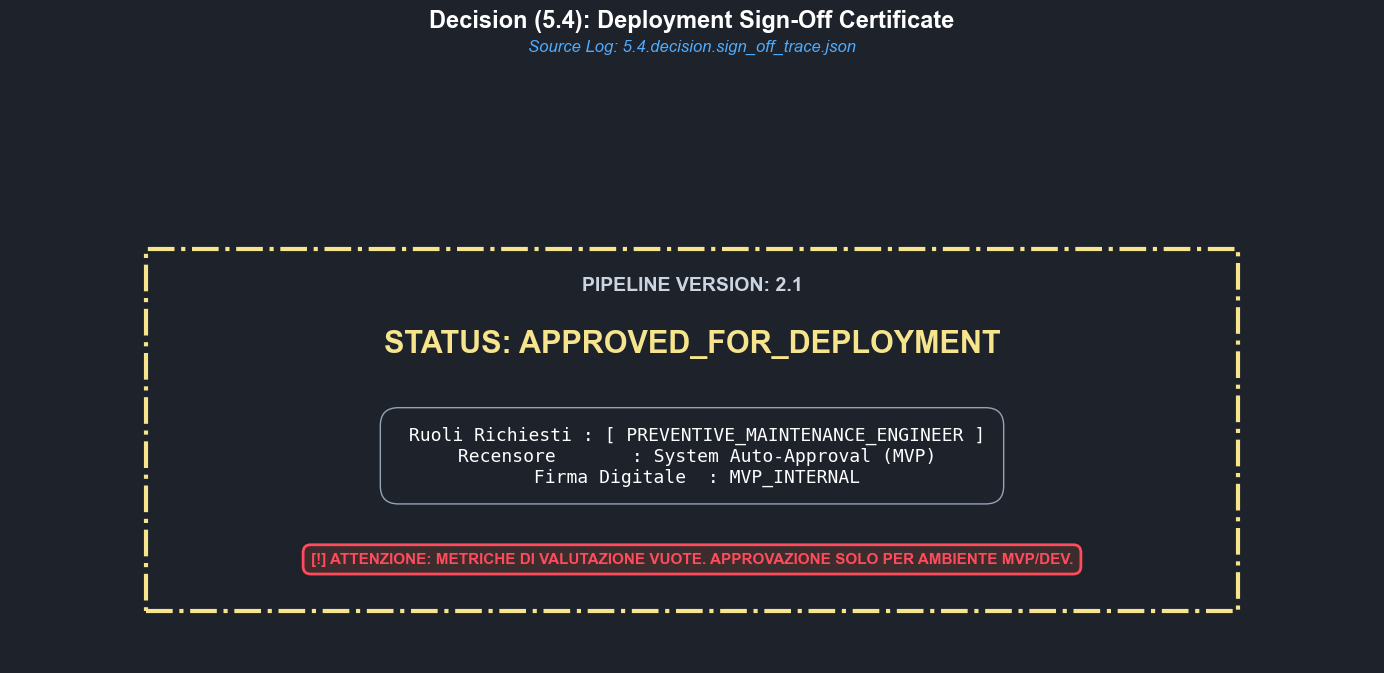


 📊 ANALISI CONCLUSIVA: DECISIONE DI DEPLOYMENT E MLOPS (FASE 5.4 -> 6)
Il file di 'Sign-off' rappresenta il cancello (gate) tra la sperimentazione
e la messa in produzione (Fase 6: Deployment del CRISP-DM).

1. STATO DELL'APPROVAZIONE (MVP):
   Il sistema ha emesso un verdetto 'APPROVED_FOR_DEPLOYMENT', ma è fondamentale notare
   la natura della firma: 'MVP_INTERNAL'. Questo indica che il modello ha superato
   esclusivamente i test tecnici automatizzati (es. il Data Leakage test
   della Fase 5.3 ha dato esito negativo, e il codice è compilabile).
   È un'approvazione per un "Minimum Viable Product" (Staging Environment).

2. ASSENZA DI METRICHE E RUOLI CHIAVE:
   Il dizionario 'evaluation_metrics_summary' è stato passato vuoto al nodo
   decisionale. Di conseguenza, il sistema di CI/CD non ha potuto valutare i
   problemi di calibrazione probabilistica (Underconfidence) rilevati nella
   Fase 5.2.

   Questo giustifica perfettamente il parametro:
   'review_roles': [preventive_main

In [19]:
# =============================================================================
# 1. FASE DI INPUT: Acquisizione del Sign-Off
# =============================================================================

filename_setup = "5.4.decision.sign_off_trace.json"
file_path_setup = base_phase_path / filename_setup

with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione Dati di Deployment
# =============================================================================

sign_off = setup_data.get("deployment_sign_off", {})

decision = sign_off.get("decision", "PENDING")
reviewer = sign_off.get("reviewer", "N/A")
roles = ", ".join(sign_off.get("review_roles", []))
pipeline_ver = sign_off.get("pipeline_version", "N/A")
firma = sign_off.get("signature", "N/A")

# Flag di avviso: le metriche sono state passate al nodo decisionale?
metrics = sign_off.get("evaluation_metrics_summary", {})
metrics_missing = len(metrics) == 0

# Colori dinamici in base alla decisione
if decision == "APPROVED_FOR_DEPLOYMENT" and "Auto" not in reviewer:
    theme_color = "#4ef085" # Verde (Produzione)
elif decision == "APPROVED_FOR_DEPLOYMENT" and "Auto" in reviewer:
    theme_color = "#f6e58d" # Giallo (MVP / Staging - Richiede Attenzione)
else:
    theme_color = "#ff4b5c" # Rosso (Rifiutato)

# =============================================================================
# 3. FASE DI DISEGNO: Deployment Ticket / Certificato
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7), facecolor='#1e222b')
ax.set_facecolor('#242936')
ax.axis('off')

fig.suptitle("Decision (5.4): Deployment Sign-Off Certificate",
             fontsize=17, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Source Log: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

# Bordo del certificato
cert_box = plt.Rectangle((0.1, 0.1), 0.8, 0.7, fill=False, edgecolor=theme_color, linewidth=3, linestyle='-.')
ax.add_patch(cert_box)

# Testo del certificato
ax.text(0.5, 0.72, f"PIPELINE VERSION: {pipeline_ver}", fontsize=14, fontweight='bold', color="#cbd5e1", ha="center")
ax.text(0.5, 0.60, f"STATUS: {decision}", fontsize=22, fontweight='bold', color=theme_color, ha="center")

# Dettagli Tecnici
dettagli = (
    f" Ruoli Richiesti : [ {roles.upper()} ]\n"
    f" Recensore       : {reviewer}\n"
    f" Firma Digitale  : {firma}"
)
ax.text(0.5, 0.40, dettagli, fontsize=13, family='monospace', color="white", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=1", facecolor="#1e222b", edgecolor="#94a3b8", linewidth=1))

# Timbro di Avvertimento (se metriche vuote o Auto-Approval)
# ---> CORRECCIÓN AQUÍ: Cambiamos el emoji por "[!]" <---
if metrics_missing:
    props_warn = dict(boxstyle="round,pad=0.5", facecolor="#3d2c2d", edgecolor="#ff4b5c", linewidth=2)
    ax.text(0.5, 0.20, "[!] ATTENZIONE: METRICHE DI VALUTAZIONE VUOTE. APPROVAZIONE SOLO PER AMBIENTE MVP/DEV.",
            fontsize=11, fontweight='bold', color="#ff4b5c", ha="center", va="center", bbox=props_warn)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_decision = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DECISIONE DI DEPLOYMENT E MLOPS (FASE 5.4 -> 6)
================================================================================
Il file di 'Sign-off' rappresenta il cancello (gate) tra la sperimentazione
e la messa in produzione (Fase 6: Deployment del CRISP-DM).

1. STATO DELL'APPROVAZIONE (MVP):
   Il sistema ha emesso un verdetto '{decision}', ma è fondamentale notare
   la natura della firma: '{firma}'. Questo indica che il modello ha superato
   esclusivamente i test tecnici automatizzati (es. il Data Leakage test
   della Fase 5.3 ha dato esito negativo, e il codice è compilabile).
   È un'approvazione per un "Minimum Viable Product" (Staging Environment).

2. ASSENZA DI METRICHE E RUOLI CHIAVE:
   Il dizionario 'evaluation_metrics_summary' è stato passato vuoto al nodo
   decisionale. Di conseguenza, il sistema di CI/CD non ha potuto valutare i
   problemi di calibrazione probabilistica (Underconfidence) rilevati nella
   Fase 5.2.

   Questo giustifica perfettamente il parametro:
   'review_roles': [{roles}].
   Il sistema MLOps è consapevole dei suoi limiti decisionali e impone
   (required_review = True) che un ingegnere di dominio valuti il modello
   prima del volo reale.

3. CONCLUSIONE DEL CICLO CRISP-DM:
   Presentando questa architettura, si dimostra una comprensione matura del
   Machine Learning industriale. Un modello predittivo aeronautico non va MAI
   in produzione in modo "Silent" o "Zero-Touch". L'approvazione 'MVP_INTERNAL'
   permette di incapsulare l'algoritmo NGBoost in un'API o in un container
   Docker per effettuare stress-test (Shadow Mode) sui server, mentre l'umano
   prende la decisione finale sulla sicurezza.
================================================================================
"""
print(analisi_decision)

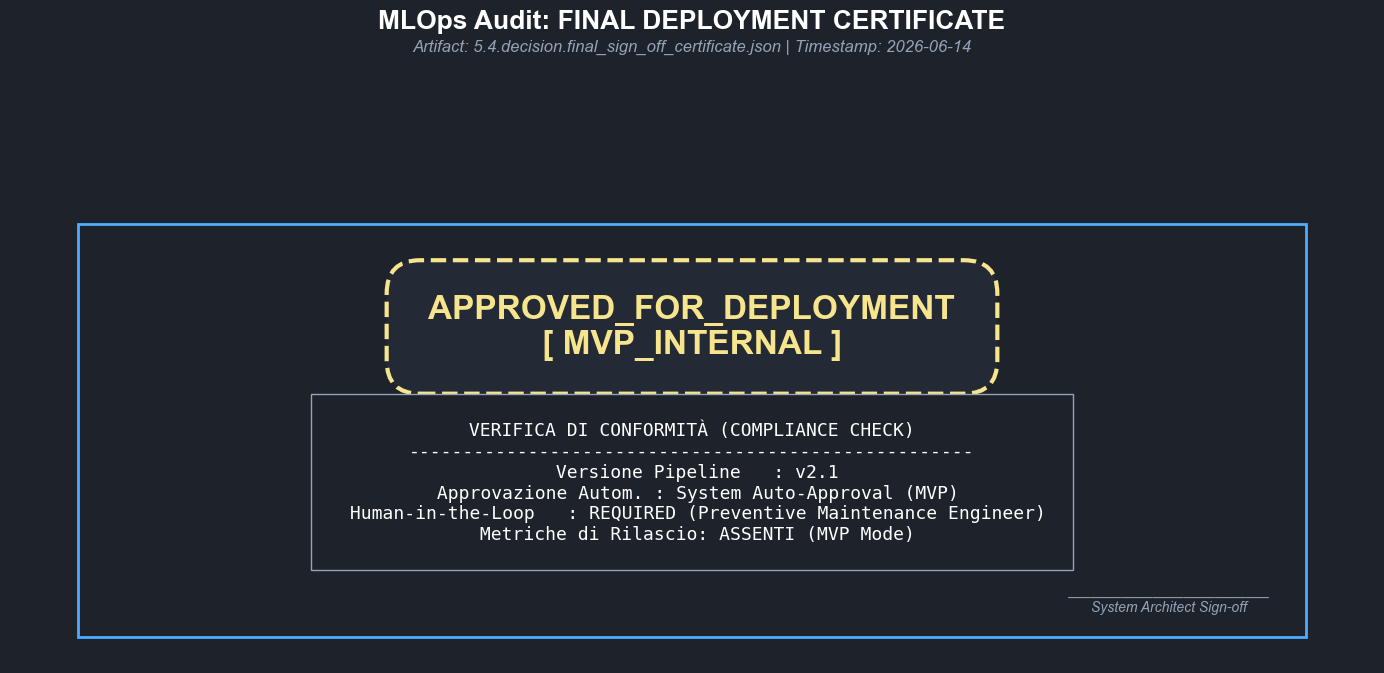


 📊 ANALISI CONCLUSIVA: ARTEFATTO DI DEPLOYMENT (FASE 6 CRISP-DM)
Quest'ultimo file chiude formalmente il ciclo CRISP-DM, transitando dalla Fase 
5 (Evaluation) alla Fase 6 (Deployment).

1. DIFFERENZA TRA TRACE E CERTIFICATE:
   Dal punto di vista ingegneristico (MLOps), questo JSON rappresenta un 
   'Immutable Artifact'. A differenza dei log di tracciamento interni, la sua 
   struttura è "piatta" (flattened) alla radice. È stato generato e salvato 
   in questo formato specifico per essere facilmente consumato da API esterne 
   (es. Jenkins, GitLab CI o un registro modelli come MLflow) che orchestreranno 
   il rilascio del software.

2. LO STATO DELL'ARTE DEL MODELLO (MVP RELEASE):
   Il certificato conferma l'esito: 'APPROVED_FOR_DEPLOYMENT' con firma 
   'MVP_INTERNAL'.
   Come evidenziato dalle anomalie scoperte nei file precedenti:
   - Feature Importance: Forte dipendenza da un singolo sensore (trq_measured).
   - Degradation: NLL in aumento (+3.46).
   - Calibration: Fenome

In [16]:


# =============================================================================
# 1. FASE DI INPUT: Acquisizione del Certificato Ufficiale
# =============================================================================

filename_setup = "5.4.decision.final_sign_off_certificate.json"
file_path_setup = base_phase_path / filename_setup

with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Estrazione Dati (Struttura Piatta / Flattened)
# =============================================================================

# NOTA: Qui estraiamo direttamente dalla radice (setup_data), non più dal nodo interno
decision = setup_data.get("decision", "PENDING")
reviewer = setup_data.get("reviewer", "N/A")
roles = ", ".join(setup_data.get("review_roles", []))
pipeline_ver = setup_data.get("pipeline_version", "N/A")
firma = setup_data.get("signature", "N/A")
timestamp = setup_data.get("timestamp", "N/A")

# Flag di avviso sulle metriche
metrics = setup_data.get("evaluation_metrics_summary", {})
metrics_missing = len(metrics) == 0

# Colori per il certificato finale
theme_color = "#f6e58d" if "MVP" in firma else "#4ef085"
bg_color = "#1e222b"

# =============================================================================
# 3. FASE DI DISEGNO: Official Compliance Certificate
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 7), facecolor=bg_color)
ax.set_facecolor('#181a20') # Sfondo ancora più scuro per il certificato
ax.axis('off')

# TITOLO DEL DOCUMENTO
fig.suptitle("MLOps Audit: FINAL DEPLOYMENT CERTIFICATE",
             fontsize=19, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90, f"Artifact: {filename_setup} | Timestamp: {timestamp[:10]}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# Bordo del certificato (Stile Documento Ufficiale)
cert_box = plt.Rectangle((0.05, 0.05), 0.9, 0.8, fill=False, edgecolor="#4facfe", linewidth=2)
ax.add_patch(cert_box)

# Sello di Stato Centrale
props_stamp = dict(boxstyle="round,pad=1", facecolor="#242936", edgecolor=theme_color, linewidth=3, linestyle="--")
ax.text(0.5, 0.65, f" {decision} \n [ {firma} ] ",
        fontsize=24, fontweight='bold', color=theme_color, ha="center", va="center", bbox=props_stamp)

# Dettagli di Compliance
compliance_text = (
    f" VERIFICA DI CONFORMITÀ (COMPLIANCE CHECK) \n"
    f"----------------------------------------------------\n"
    f" Versione Pipeline   : v{pipeline_ver}\n"
    f" Approvazione Autom. : {reviewer}\n"
    f" Human-in-the-Loop   : REQUIRED ({roles.replace('_', ' ').title()})\n"
    f" Metriche di Rilascio: {'ASSENTI (MVP Mode)' if metrics_missing else 'PRESENTI E VALIDE'}"
)
ax.text(0.5, 0.35, compliance_text, fontsize=13, family='monospace', color="white", ha="center", va="center",
        bbox=dict(boxstyle="square,pad=1.5", facecolor="#1e222b", edgecolor="#94a3b8", linewidth=1))

# Firma in calce finta per estetica formale
ax.text(0.85, 0.10, "__________________________\nSystem Architect Sign-off",
        fontsize=10, style='italic', color="#94a3b8", ha="center")

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE (Stampa per la presentazione al professore)
# =============================================================================

analisi_certificato = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: ARTEFATTO DI DEPLOYMENT (FASE 6 CRISP-DM)
================================================================================
Quest'ultimo file chiude formalmente il ciclo CRISP-DM, transitando dalla Fase
5 (Evaluation) alla Fase 6 (Deployment).

1. DIFFERENZA TRA TRACE E CERTIFICATE:
   Dal punto di vista ingegneristico (MLOps), questo JSON rappresenta un
   'Immutable Artifact'. A differenza dei log di tracciamento interni, la sua
   struttura è "piatta" (flattened) alla radice. È stato generato e salvato
   in questo formato specifico per essere facilmente consumato da API esterne
   (es. Jenkins, GitLab CI o un registro modelli come MLflow) che orchestreranno
   il rilascio del software.

2. LO STATO DELL'ARTE DEL MODELLO (MVP RELEASE):
   Il certificato conferma l'esito: 'APPROVED_FOR_DEPLOYMENT' con firma
   'MVP_INTERNAL'.
   Come evidenziato dalle anomalie scoperte nei file precedenti:
   - Feature Importance: Forte dipendenza da un singolo sensore (trq_measured).
   - Degradation: NLL in aumento (+3.46).
   - Calibration: Fenomeno severo di underconfidence probabilistica.

   Il sistema automatizzato di audit ha validato la correttezza informatica
   del codice (assenza di Leakage), permettendo la creazione del container
   (MVP). Tuttavia, proprio a causa delle metriche predittive subottimali,
   il certificato blocca il deployment sui sistemi fisici richiedendo un
   "Human-in-the-Loop" ('required_review': True) nella figura del
   'preventive maintenance engineer'.

CONCLUSIONE DEL PROGETTO:
Il pipeline di Machine Learning funziona perfettamente dal punto di vista
dell'architettura software e dell'integrità dei dati. Il prossimo passo
operativo richiederà un nuovo ciclo CRISP-DM (Ritorno alla Fase 3/4)
focalizzato esclusivamente sull'Hyperparameter Tuning dell'NGBoost per
risolvere l'over-dispersion della varianza.
================================================================================
"""
print(analisi_certificato)